<a href="https://colab.research.google.com/github/ketanp23/deeplearningclass/blob/main/DL_Lab8_Optimizers_Momentum_RMSProp_Adam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DL Lab 8 · Optimizers — Momentum, RMSProp & Adam

> **Deep Learning foundations — Lab 8 (Part II).** A deeper companion to **Lab 3 (Gradient Descent)**. Run top to bottom
> (Runtime → Run all), read the plain-English notes, and finish the **Your turn 🧪** cell. Built from scratch with
> NumPy so nothing is hidden.

### In plain English
Lab 3 used plain gradient descent: step downhill by the slope. On real loss surfaces that crawls through narrow
valleys and stalls on plateaus. Modern optimizers add **memory**: momentum builds up speed in consistent directions,
RMSProp adapts the step size per-parameter, and **Adam** combines both. We build all three from scratch and race them
on an ill-conditioned bowl.

In [1]:
import numpy as np, matplotlib.pyplot as plt
VIOLET,CYAN,AMBER,GREEN,ROSE="#6C5CE7","#22D3EE","#F59E0B","#10B981","#FB7185"

# an ill-conditioned bowl: gentle in x, steep in y -> plain GD zig-zags
A=np.array([0.1,25.0])
def loss(p):  return 0.5*np.sum(A*p**2)
def grad(p):  return A*p

## 1 · Four optimizers, from scratch

In [2]:
def run(update, steps=200, lr=0.06, start=(9.,3.)):
    p=np.array(start,float); state={}; path=[p.copy()]
    for t in range(1,steps+1):
        g=grad(p); p=update(p,g,lr,state,t); path.append(p.copy())
    return np.array(path)

def sgd(p,g,lr,s,t): return p-lr*g
def momentum(p,g,lr,s,t):
    s['v']=0.9*s.get('v',0)-lr*g; return p+s['v']
def rmsprop(p,g,lr,s,t):
    s['a']=0.9*s.get('a',0)+0.1*g**2; return p-lr*g/(np.sqrt(s['a'])+1e-8)
def adam(p,g,lr,s,t):
    s['m']=0.9*s.get('m',0)+0.1*g; s['v']=0.999*s.get('v',0)+0.001*g**2
    mh=s['m']/(1-0.9**t); vh=s['v']/(1-0.999**t)
    return p-lr*mh/(np.sqrt(vh)+1e-8)

opts={"SGD":(sgd,VIOLET),"Momentum":(momentum,CYAN),"RMSProp":(rmsprop,AMBER),"Adam":(adam,GREEN)}
for name,(u,_) in opts.items():
    path=run(u); print(f"{name:9s} final loss {loss(path[-1]):.4f}  after 200 steps")

SGD       final loss 0.3648  after 200 steps
Momentum  final loss 0.0000  after 200 steps
RMSProp   final loss 0.0085  after 200 steps
Adam      final loss 0.0604  after 200 steps


## 2 · Watch them descend the valley

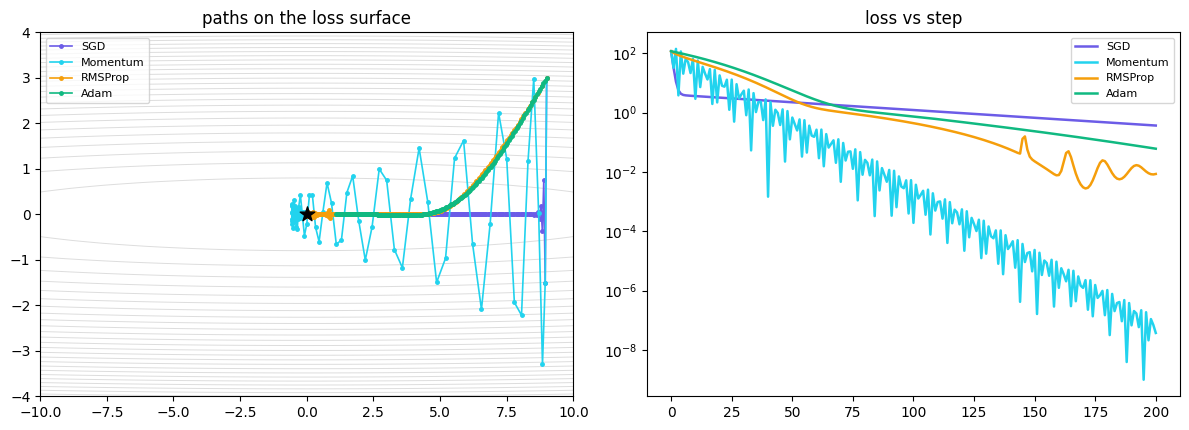

Plain SGD zig-zags across the steep y-axis; Adam/RMSProp rescale each axis and go nearly straight in.


In [3]:
xx,yy=np.meshgrid(np.linspace(-10,10,120),np.linspace(-4,4,120))
Z=0.5*(A[0]*xx**2+A[1]*yy**2)
fig,ax=plt.subplots(1,2,figsize=(12,4.4))
ax[0].contour(xx,yy,Z,levels=25,colors="#ddd",linewidths=.7)
for name,(u,c) in opts.items():
    P=run(u); ax[0].plot(P[:,0],P[:,1],'o-',color=c,ms=2.5,lw=1.2,label=name)
    ax[1].plot([loss(p) for p in P],color=c,lw=1.8,label=name)
ax[0].set_title("paths on the loss surface"); ax[0].legend(fontsize=8); ax[0].scatter([0],[0],c='k',marker='*',s=120,zorder=5)
ax[1].set_yscale("log"); ax[1].set_title("loss vs step"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Plain SGD zig-zags across the steep y-axis; Adam/RMSProp rescale each axis and go nearly straight in.")

## 3 · Learning-rate schedules

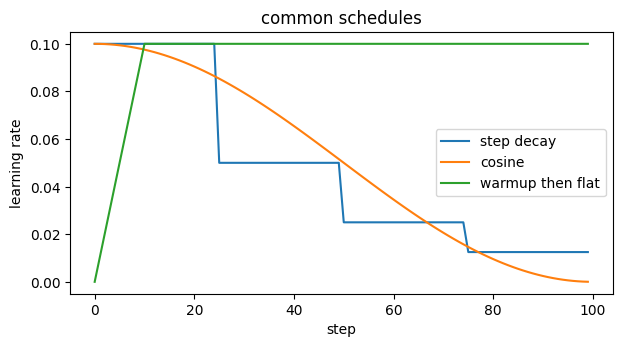

In [4]:
steps=np.arange(100)
step_decay = 0.1*0.5**(steps//25)
cosine     = 0.1*0.5*(1+np.cos(np.pi*steps/100))
warmup     = np.minimum(steps/10, 1.0)*0.1
plt.figure(figsize=(7,3.4))
for s,l in [(step_decay,"step decay"),(cosine,"cosine"),(warmup,"warmup then flat")]:
    plt.plot(steps,s,label=l)
plt.xlabel("step"); plt.ylabel("learning rate"); plt.title("common schedules"); plt.legend(); plt.show()

## 4 · Mini-batch vs full-batch
Real training estimates the gradient from a small **mini-batch** — cheaper, and the noise even helps escape bad spots.
Here we fit a line and compare the loss curves.

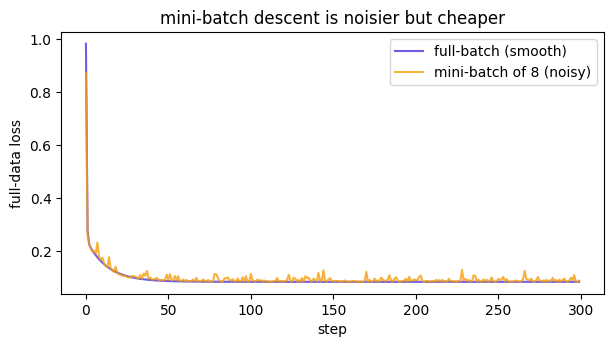

In [5]:
rng=np.random.default_rng(0)
xd=np.linspace(0,1,200); yd=3*xd+2+rng.normal(0,0.3,200)
def fit(batch, steps=300, lr=0.3):
    w,b=0.,0.; hist=[]
    for t in range(steps):
        idx=rng.choice(200,batch,replace=False)
        xb,yb=xd[idx],yd[idx]; pred=w*xb+b; err=pred-yb
        w-=lr*(2*err*xb).mean(); b-=lr*(2*err).mean()
        hist.append(np.mean((w*xd+b-yd)**2))
    return hist
plt.figure(figsize=(7,3.4))
plt.plot(fit(200),label="full-batch (smooth)",color=VIOLET)
plt.plot(fit(8),label="mini-batch of 8 (noisy)",color=AMBER,alpha=.8)
plt.xlabel("step"); plt.ylabel("full-data loss"); plt.legend(); plt.title("mini-batch descent is noisier but cheaper"); plt.show()

## Your turn 🧪
1. Add a **saddle** term (e.g. `loss = x**2 - y**2`) and see which optimizers escape it fastest.
2. Tune Adam's learning rate. Can plain SGD ever match Adam here by using a *much* smaller lr? At what cost in steps?
3. Combine Adam with the cosine schedule from section 3 and plot the resulting path.

In [6]:
# Your turn: Adam vs finely-tuned SGD on the ill-conditioned bowl
print("Adam @0.06,  200 steps:", round(loss(run(adam,200,0.06)[-1]),4))
print("SGD  @0.06,  200 steps:", round(loss(run(sgd,200,0.06)[-1]),4), " <- stuck on the flat axis")
print("SGD  @0.06, 3000 steps:", round(loss(run(sgd,3000,0.06)[-1]),4), " <- SGD gets there eventually, just far slower")

Adam @0.06,  200 steps: 0.0604
SGD  @0.06,  200 steps: 0.3648  <- stuck on the flat axis
SGD  @0.06, 3000 steps: 0.0  <- SGD gets there eventually, just far slower
